In [1]:
from google.colab import files
uploaded = files.upload()

Saving UWOC_useing_photoresistor-main.zip to UWOC_useing_photoresistor-main.zip


In [4]:
import zipfile
import io

# Assuming the uploaded file is in the 'uploaded' dictionary
# The file was uploaded as 'UWOC_useing_photoresistor-main.zip'
zip_file_name = 'UWOC_useing_photoresistor-main.zip'

# Unzip the file
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
    z.extractall('.')
print(f"Extracted {zip_file_name} contents.")

Extracted UWOC_useing_photoresistor-main.zip contents.


In [5]:
import pandas as pd

df = pd.read_csv('UWOC_useing_photoresistor-main/anaotherGUI/1-2NTU.csv')
print(df.shape)
df.head()

(8512, 3)


,labels,feature,bit
0,0,0.346680,0
1,0,0.346680,0
2,0,0.346680,0
3,1,0.532227,1
4,0,0.346680,0


In [6]:
# Check for missing values
print(df.isnull().sum())

# Check class balance
print(df['labels'].value_counts())

# Basic stats on the feature column
print(df['feature'].describe())

labels     0
feature    0
bit        0
dtype: int64
labels
0    5321
1    3191
Name: count, dtype: int64
count    8512.000000
mean        0.416311
std         0.087772
min         0.336914
25%         0.346680
50%         0.351562
75%         0.527344
max         0.625000
Name: feature, dtype: float64


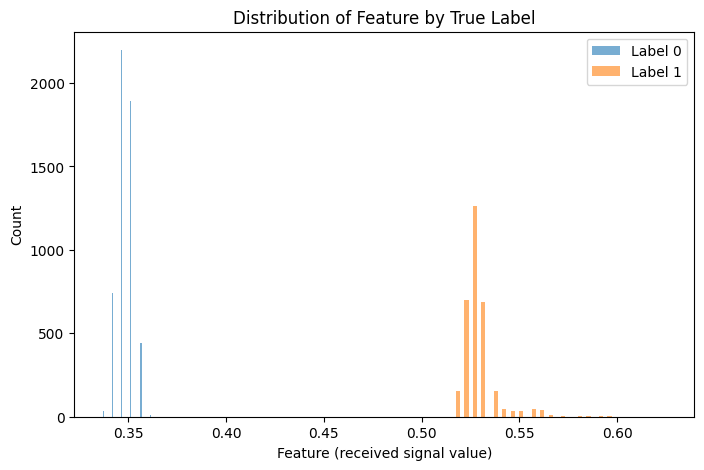

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df[df['labels']==0]['feature'], bins=50, alpha=0.6, label='Label 0')
plt.hist(df[df['labels']==1]['feature'], bins=50, alpha=0.6, label='Label 1')
plt.xlabel('Feature (received signal value)')
plt.ylabel('Count')
plt.title('Distribution of Feature by True Label')
plt.legend()
plt.show()

In [8]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Simple fixed threshold, right in the gap
threshold = 0.44
df['threshold_pred'] = (df['feature'] > threshold).astype(int)

acc = accuracy_score(df['labels'], df['threshold_pred'])
f1 = f1_score(df['labels'], df['threshold_pred'])
cm = confusion_matrix(df['labels'], df['threshold_pred'])

print("Accuracy:", acc)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[5321    0]
 [   0 3191]]


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[['feature']]
y = df['labels']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression F1:", f1_score(y_test, y_pred))

Logistic Regression Accuracy: 1.0
Logistic Regression F1: 1.0


In [10]:
print("Duplicate rows:", df.duplicated().sum())
print("Unique labels:", df['labels'].unique())
print("Unique bit values:", df['bit'].unique())

Duplicate rows: 8486
Unique labels: [0 1]
Unique bit values: [0 1]


In [11]:
print("Unique feature values:", df['feature'].nunique())
print(df['feature'].value_counts())

Unique feature values: 26
feature
0.346680    2198
0.351562    1890
0.527344    1265
0.341797     743
0.522461     700
0.532227     687
0.356445     444
0.517578     153
0.537109     152
0.541992      49
0.556641      47
0.561523      40
0.546875      35
0.551758      35
0.336914      32
0.361328      13
0.566406      11
0.581055       4
0.590820       3
0.571289       3
0.585938       2
0.595703       2
0.576172       1
0.625000       1
0.366211       1
0.600586       1
Name: count, dtype: int64


In [12]:
class_stats = df.groupby('labels')['feature'].describe()
print(class_stats)

         count      mean       std       min       25%       50%       75%  \
labels                                                                       
0       5321.0  0.348528  0.004185  0.336914  0.346680  0.346680  0.351562   
1       3191.0  0.529339  0.009045  0.517578  0.522461  0.527344  0.532227   

             max  
labels            
0       0.366211  
1       0.625000  


In [13]:
agreement = (df['bit'] == df['labels']).mean()
print("Agreement between 'bit' column and true 'labels':", agreement)

Agreement between 'bit' column and true 'labels': 1.0


<Figure size 600x500 with 0 Axes>

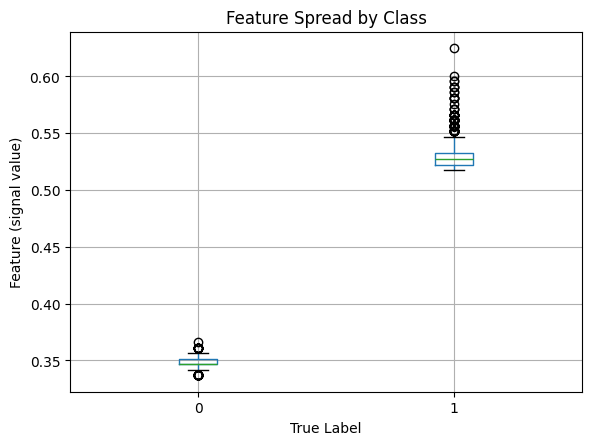

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
df.boxplot(column='feature', by='labels')
plt.title('Feature Spread by Class')
plt.suptitle('')
plt.xlabel('True Label')
plt.ylabel('Feature (signal value)')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

# Drop the leakage-risk column before modelling
X = df[['feature']]
y = df['labels']

# Stratified 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Val class balance:\n", y_val.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train: (5958, 1) Val: (1277, 1) Test: (1277, 1)
Train class balance:
 labels
0    0.625042
1    0.374958
Name: proportion, dtype: float64
Val class balance:
 labels
0    0.624902
1    0.375098
Name: proportion, dtype: float64
Test class balance:
 labels
0    0.625685
1    0.374315
Name: proportion, dtype: float64


In [16]:
import os

os.makedirs('processed_data', exist_ok=True)

X_train.assign(labels=y_train).to_csv('processed_data/train.csv', index=False)
X_val.assign(labels=y_val).to_csv('processed_data/val.csv', index=False)
X_test.assign(labels=y_test).to_csv('processed_data/test.csv', index=False)

print("Saved train/val/test CSVs to processed_data/")

Saved train/val/test CSVs to processed_data/


baseline classification


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- Fixed threshold baseline ---
threshold = 0.44
y_test_thresh_pred = (X_test['feature'] > threshold).astype(int)

acc_t = accuracy_score(y_test, y_test_thresh_pred)
prec_t = precision_score(y_test, y_test_thresh_pred)
rec_t = recall_score(y_test, y_test_thresh_pred)
f1_t = f1_score(y_test, y_test_thresh_pred)
cm_t = confusion_matrix(y_test, y_test_thresh_pred)
ber_t = 1 - rec_t  # simplified BER proxy: error rate on bit detection

print("=== Fixed Threshold Baseline (Test Set) ===")
print("Accuracy:", acc_t, "Precision:", prec_t, "Recall:", rec_t, "F1:", f1_t)
print("BER (approx):", ber_t)
print("Confusion Matrix:\n", cm_t)

# --- Logistic Regression baseline ---
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
y_test_lr_pred = model_lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_test_lr_pred)
prec_lr = precision_score(y_test, y_test_lr_pred)
rec_lr = recall_score(y_test, y_test_lr_pred)
f1_lr = f1_score(y_test, y_test_lr_pred)
cm_lr = confusion_matrix(y_test, y_test_lr_pred)

print("\n=== Logistic Regression Baseline (Test Set) ===")
print("Accuracy:", acc_lr, "Precision:", prec_lr, "Recall:", rec_lr, "F1:", f1_lr)
print("Confusion Matrix:\n", cm_lr)

=== Fixed Threshold Baseline (Test Set) ===
Accuracy: 1.0 Precision: 1.0 Recall: 1.0 F1: 1.0
BER (approx): 0.0
Confusion Matrix:
 [[799   0]
 [  0 478]]

=== Logistic Regression Baseline (Test Set) ===
Accuracy: 1.0 Precision: 1.0 Recall: 1.0 F1: 1.0
Confusion Matrix:
 [[799   0]
 [  0 478]]


In [18]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# --- SVM ---
model_svm = SVC(random_state=42)
model_svm.fit(X_train, y_train)
y_test_svm_pred = model_svm.predict(X_test)

print("=== SVM (Test Set) ===")
print("Accuracy:", accuracy_score(y_test, y_test_svm_pred))
print("Precision:", precision_score(y_test, y_test_svm_pred))
print("Recall:", recall_score(y_test, y_test_svm_pred))
print("F1:", f1_score(y_test, y_test_svm_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_svm_pred))

# --- Random Forest ---
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_test_rf_pred = model_rf.predict(X_test)

print("\n=== Random Forest (Test Set) ===")
print("Accuracy:", accuracy_score(y_test, y_test_rf_pred))
print("Precision:", precision_score(y_test, y_test_rf_pred))
print("Recall:", recall_score(y_test, y_test_rf_pred))
print("F1:", f1_score(y_test, y_test_rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_rf_pred))

=== SVM (Test Set) ===
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Confusion Matrix:
 [[799   0]
 [  0 478]]

=== Random Forest (Test Set) ===
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Confusion Matrix:
 [[799   0]
 [  0 478]]


In [19]:
from sklearn.neural_network import MLPClassifier

model_mlp = MLPClassifier(hidden_layer_sizes=(8,), max_iter=1000, random_state=42)
model_mlp.fit(X_train, y_train)
y_test_mlp_pred = model_mlp.predict(X_test)

print("=== Small MLP (Test Set) ===")
print("Accuracy:", accuracy_score(y_test, y_test_mlp_pred))
print("Precision:", precision_score(y_test, y_test_mlp_pred))
print("Recall:", recall_score(y_test, y_test_mlp_pred))
print("F1:", f1_score(y_test, y_test_mlp_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_mlp_pred))

# Check validation behavior during training
print("\nFinal training loss:", model_mlp.loss_)
print("Number of iterations run:", model_mlp.n_iter_)

=== Small MLP (Test Set) ===
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Confusion Matrix:
 [[799   0]
 [  0 478]]

Final training loss: 0.004124227640957506
Number of iterations run: 209


In [20]:
import time

models = {
    "Fixed Threshold": None,
    "Logistic Regression": model_lr,
    "SVM": model_svm,
    "Random Forest": model_rf,
    "MLP": model_mlp
}

results = []

for name, model in models.items():
    start = time.time()
    if name == "Fixed Threshold":
        preds = (X_test['feature'] > threshold).astype(int)
    else:
        preds = model.predict(X_test)
    elapsed = time.time() - start

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "Inference Time (s)": elapsed
    })

comparison_df = pd.DataFrame(results)
print(comparison_df)

                 Model  Accuracy  Precision  Recall   F1  Inference Time (s)
0      Fixed Threshold       1.0        1.0     1.0  1.0            0.000573
1  Logistic Regression       1.0        1.0     1.0  1.0            0.001133
2                  SVM       1.0        1.0     1.0  1.0            0.001754
3        Random Forest       1.0        1.0     1.0  1.0            0.009923
4                  MLP       1.0        1.0     1.0  1.0            0.001245


In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(
    LogisticRegression(), param_grid, cv=5, scoring='f1'
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated F1:", grid_search.best_score_)

# Evaluate the tuned model on validation set (not test yet!)
best_model = grid_search.best_estimator_
y_val_pred = best_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation F1:", f1_score(y_val, y_val_pred))

Best parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best cross-validated F1: 1.0
Validation Accuracy: 1.0
Validation F1: 1.0


In [24]:
import numpy as np
import pandas as pd

noise_levels = [0.0, 0.01, 0.02, 0.03, 0.05, 0.08]
robustness_results = []

for noise_std in noise_levels:
    np.random.seed(42)
    noisy_feature = X_test['feature'] + np.random.normal(0, noise_std, size=len(X_test))

    # Threshold prediction on noisy signal
    thresh_pred = (noisy_feature > threshold).astype(int)
    thresh_acc = accuracy_score(y_test, thresh_pred)
    thresh_f1 = f1_score(y_test, thresh_pred)

    # Logistic Regression prediction on noisy signal
    # Convert noisy_feature back to a DataFrame with the correct feature name
    noisy_feature_df = pd.DataFrame(noisy_feature, columns=['feature'])
    lr_pred = model_lr.predict(noisy_feature_df)
    lr_acc = accuracy_score(y_test, lr_pred)
    lr_f1 = f1_score(y_test, lr_pred)

    robustness_results.append({
        "Simulated Noise (proxy for turbidity)": noise_std,
        "Threshold Accuracy": thresh_acc,
        "Threshold F1": thresh_f1,
        "LogReg Accuracy": lr_acc,
        "LogReg F1": lr_f1
    })

robustness_df = pd.DataFrame(robustness_results)
print(robustness_df)

   Simulated Noise (proxy for turbidity)  Threshold Accuracy  Threshold F1  \
0                                   0.00            1.000000      1.000000   
1                                   0.01            1.000000      1.000000   
2                                   0.02            1.000000      1.000000   
3                                   0.03            0.999217      0.998953   
4                                   0.05            0.967894      0.957336   
5                                   0.08            0.877839      0.843058   

   LogReg Accuracy  LogReg F1  
0         1.000000   1.000000  
1         1.000000   1.000000  
2         1.000000   1.000000  
3         0.998434   0.997904  
4         0.969460   0.958904  
5         0.879405   0.840909  


In [25]:
import joblib
import os

os.makedirs('final_model', exist_ok=True)

# Freeze the final chosen model
joblib.dump(model_lr, 'final_model/logistic_regression_final.pkl')

print("Final model saved to final_model/logistic_regression_final.pkl")
print("Model coefficients:", model_lr.coef_)
print("Model intercept:", model_lr.intercept_)

Final model saved to final_model/logistic_regression_final.pkl
Model coefficients: [[30.75332034]]
Model intercept: [-13.75958524]


In [26]:
import time

# Final validation on the held-out test set using the frozen pipeline
start = time.time()
y_test_final_pred = model_lr.predict(X_test)
final_inference_time = time.time() - start

final_acc = accuracy_score(y_test, y_test_final_pred)
final_f1 = f1_score(y_test, y_test_final_pred)

print("=== Final Validation (Frozen Logistic Regression) ===")
print("Test Accuracy:", final_acc)
print("Test F1:", final_f1)
print("Total inference time (all test samples):", final_inference_time)
print("Per-sample inference time:", final_inference_time / len(X_test))

import os
model_size_kb = os.path.getsize('final_model/logistic_regression_final.pkl') / 1024
print("Model file size (KB):", model_size_kb)

=== Final Validation (Frozen Logistic Regression) ===
Test Accuracy: 1.0
Test F1: 1.0
Total inference time (all test samples): 0.005980730056762695
Per-sample inference time: 4.683422127457083e-06
Model file size (KB): 1.1083984375


In [27]:
np.random.seed(42)
noise_std = 0.08
noisy_feature_high = X_test['feature'] + np.random.normal(0, noise_std, size=len(X_test))
lr_pred_high_noise = model_lr.predict(noisy_feature_high.values.reshape(-1, 1))

errors_df = pd.DataFrame({
    'true_label': y_test.values,
    'original_feature': X_test['feature'].values,
    'noisy_feature': noisy_feature_high.values,
    'predicted': lr_pred_high_noise
})
errors_only = errors_df[errors_df['true_label'] != errors_df['predicted']]

print("Total errors at noise level 0.08:", len(errors_only))
print("\nError breakdown by true class:")
print(errors_only['true_label'].value_counts())
print("\nSample of misclassified rows:")
print(errors_only.head(10))
print("\nHow far the noisy value drifted from the original decision boundary (0.4474):")
print((errors_only['noisy_feature'] - 0.4474).describe())

Total errors at noise level 0.08: 154

Error breakdown by true class:
true_label
0    83
1    71
Name: count, dtype: int64

Sample of misclassified rows:
    true_label  original_feature  noisy_feature  predicted
6            0          0.346680       0.473017          1
19           1          0.527344       0.414359          0
20           0          0.351562       0.468814          1
26           1          0.527344       0.435264          0
31           0          0.351562       0.499745          1
33           1          0.527344       0.442727          0
38           1          0.527344       0.421089          0
44           1          0.522461       0.404179          0
63           1          0.527344       0.431647          0
71           0          0.346680       0.469723          1

How far the noisy value drifted from the original decision boundary (0.4474):
count    154.000000
mean       0.001049
std        0.049678
min       -0.161522
25%       -0.030129
50%        0.00433

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
